# Imports

In [108]:
import os
import re
import json
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    ConfusionMatrixDisplay,
)

from sklearn.linear_model import LogisticRegression

# XGBoost + LightGBM (make sure they are installed)
try:
    from xgboost import XGBClassifier
except ImportError as e:
    raise ImportError(
        "xgboost is not installed. Install with `pip install xgboost`"
    ) from e

try:
    from lightgbm import LGBMClassifier
except ImportError as e:
    raise ImportError(
        "lightgbm is not installed. Install with `pip install lightgbm`"
    ) from e

# SHAP explanations
try:
    import shap
    HAS_SHAP = True
except Exception:
    HAS_SHAP = False
    print("[WARN] SHAP not installed; skipping SHAP plots.")


# 0. Config
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Adjust this path if needed
DATA_PATH = "../../datasets/processed/final_combined.csv"

# Column names in your CSV
HEADER_COL = "headers_raw"
LABEL_COL  = "label"

OUT_DIR = "header_stage4_models"
os.makedirs(OUT_DIR, exist_ok=True)

[WARN] SHAP not installed; skipping SHAP plots.


# Load Your Dataset

In [109]:
df = pd.read_csv(DATA_PATH)

if HEADER_COL not in df.columns:
    raise ValueError(f"{HEADER_COL} column not found in {DATA_PATH}")

if LABEL_COL not in df.columns:
    raise ValueError(f"{LABEL_COL} column not found in {DATA_PATH}")

# Keep only rows that actually have headers + labels
df = df[df[HEADER_COL].notna()].copy()
df = df[df[LABEL_COL].notna()].copy()

df[LABEL_COL] = df[LABEL_COL].astype(int)
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print("[INFO] Dataset loaded for headers:")
print(df[LABEL_COL].value_counts())
print("Total rows:", len(df))

df.head()

/tmp/ipykernel_47706/3436141184.py:1: DtypeWarning: Columns (3,4,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH)


[INFO] Dataset loaded for headers:
label
1    52603
0    30334
Name: count, dtype: int64
Total rows: 82937


,id,subject,body_text,attachment_text,headers_raw,from_email,to_email,reply_to_email,date,urls,header_from_reply_mismatch,header_domain_mismatch,header_suspicious_tld,header_received_count,header_to_anomaly,header_x_mailer_anomaly,header_date_malformed,label,source
0,5d1c1a0f-9cf1-445a-947f-9e783b991fa3,Re: Local Production July 00,"Paul,\n\nAn Amendment to Appendix ""C"" will nee...",NaN,Message-ID: <6759453.1075853764638.JavaMail.ev...,carol_a._miller@dom.com,pleanza@enron.com,NaN,"Fri, 14 Jul 2000 00:37:00 -0700 (PDT)",NaN,0,0,0,0,0,1,0,0,enron
1,f9af3f88-2de1-409e-a7d1-2151c51c1740,Purchase and Sale Agreement,Attached is the latest draft of the Purchase a...,NaN,Message-ID: <30439740.1075850996586.JavaMail.e...,lance.schuler-legal@enron.com,frank.sayre@enron.com,NaN,"Sun, 13 Aug 2000 04:47:00 -0700 (PDT)",NaN,0,0,0,0,0,1,0,0,enron
2,b4fa53dd-90d6-4548-9bb5-545de34a970e,Board Luncheon on December 12th,calendar\n----- Forwarded by Steven J Kean/NA/...,NaN,Message-ID: <29827408.1075846209763.JavaMail.e...,steven.kean@enron.com,maureen.mcvicker@enron.com,NaN,"Fri, 8 Dec 2000 00:19:00 -0800 (PST)",NaN,0,0,0,0,0,1,0,0,enron
3,427d71da-b931-4064-9500-3d50480c8b31,XSS Test Mail,testtest,NaN,From: larry.gleffe@enron.com\nTo: ttaylor@smrh...,larry.gleffe@enron.com,ttaylor@smrh.com,NaN,NaN,NaN,0,0,0,0,0,1,1,1,epvme_phish
4,7b900423-4fcf-49ca-a876-5d5e89db9b9a,RE: Doc's for conference call,Please review and let me know your thoughts on...,NaN,Message-ID: <33554011.1075842749534.JavaMail.e...,gerald.nemec@enron.com,debra.perlingiere@enron.com,NaN,"Thu, 28 Dec 2000 09:30:00 -0800 (PST)",NaN,0,0,0,0,0,1,0,0,enron


# Helper functions

In [ ]:
FREEMAIL_DOMAINS = {
    "gmail.com","yahoo.com","hotmail.com","outlook.com","live.com",
    "aol.com","icloud.com","mail.com","gmx.com","yandex.ru","yandex.com",
    "zoho.com","proton.me","protonmail.com"
}

HEADER_PRESENCE_LIST = [
    "from","to","subject","date","reply-to","sender","return-path",
    "received","message-id","authentication-results","dkim-signature",
    "domainkey-signature","received-spf","x-spam-flag","x-spam-status",
    "x-originating-ip","x-mailer","mime-version","content-type",
    "content-transfer-encoding","list-id","list-unsubscribe","x-priority"
]

def _extract_first_header_line(headers: str, field: str) -> str:
    pattern = re.compile(rf"^{re.escape(field)}\s*:(.*)$", re.IGNORECASE | re.MULTILINE)
    m = pattern.search(headers)
    if not m: return ""
    line = m.group(1).strip()
    return line

def _extract_email_domain(text: str) -> str:
    m = re.search(r"[A-Z0-9._%+-]+@([A-Z0-9.-]+\.[A-Z]{2,})", text, re.IGNORECASE)
    return m.group(1).lower().strip("[]<>") if m else ""

def _is_freemail(domain: str) -> int:
    return int(domain in FREEMAIL_DOMAINS)

def _tld(domain: str) -> str:
    return domain.split(".")[-1] if domain and "." in domain else ""

def _token_stats(headers: str) -> dict:
    h = headers or ""
    length = len(h)
    lines = h.count("\n")+1
    digits = sum(c.isdigit() for c in h)
    uppers = sum(c.isupper() for c in h)
    lowers = sum(c.islower() for c in h)
    specials = sum(c in "!#$%&'*+,-./:;<=>?@[]^_`{|}~" for c in h)
    spaces = sum(c.isspace() for c in h)
    words = re.findall(r"\S+", h)
    num_words = len(words)
    avg_word_len = (sum(len(w) for w in words)/num_words) if num_words else 0
    return {
        "len_chars": length, "len_lines": lines, "count_digits": digits,
        "count_uppers": uppers, "count_lowers": lowers, "count_specials": specials,
        "count_spaces": spaces, "num_words": num_words, "avg_word_len": avg_word_len,
        "ratio_digits": digits/length if length>0 else 0.0,
        "ratio_specials": specials/length if length>0 else 0.0,
        "ratio_uppers": uppers/length if length>0 else 0.0
    }

def _presence_features(headers: str) -> dict:
    h_lower = headers.lower()
    feats = {}
    for name in HEADER_PRESENCE_LIST:
        feats[f"has_{name.replace('-', '_')}"] = int(bool(re.search(rf"^{re.escape(name)}\s*:", h_lower, flags=re.MULTILINE)))
    return feats

def _spf_dkim_dmarc_features(headers: str) -> dict:
    h = headers.lower()
    feats = {}
    for proto in ["spf","dkim","dmarc"]:
        res = re.search(rf"{proto}=(pass|fail|softfail|neutral|none|temperror|permerror)", h)
        val = res.group(1) if res else "none"
        for v in ["pass","fail","softfail","neutral","none","temperror","permerror"]:
            feats[f"{proto}_{v}"] = int(val==v)
    return feats

def _received_features(headers: str) -> dict:
    h = headers.lower()
    received_lines = re.findall(r"^received:", h, flags=re.MULTILINE)
    num_received = len(received_lines)
    private_ip_pattern = r"(10\.\d{1,3}\.\d{1,3}\.\d{1,3})|(192\.168\.\d{1,3}\.\d{1,3})|(172\.(1[6-9]|2[0-9]|3[0-1])\.\d{1,3}\.\d{1,3})"
    has_private_ip = int(bool(re.search(private_ip_pattern,h)))
    public_ips = re.findall(r"\b(?:[0-9]{1,3}\.){3}[0-9]{1,3}\b", h)
    num_public_ips = len(public_ips)
    return {"num_received": num_received,"has_private_ip_in_received": has_private_ip,"num_public_ips": num_public_ips}

def _x_spam_features(headers: str) -> dict:
    h_lower = headers.lower()
    feats = {"has_x_spam_flag":0,"x_spam_flag_yes":0,"has_x_spam_status":0,"x_spam_status_yes":0}
    m_flag = re.search(r"^x-spam-flag:\s*(\S+)", h_lower, flags=re.MULTILINE)
    if m_flag: feats["has_x_spam_flag"]=1; feats["x_spam_flag_yes"]=int("yes" in m_flag.group(1))
    m_stat = re.search(r"^x-spam-status:\s*(\S+)", h_lower, flags=re.MULTILINE)
    if m_stat: feats["has_x_spam_status"]=1; feats["x_spam_status_yes"]=int("yes" in m_stat.group(1))
    return feats

def extract_header_features(headers: str) -> dict:
    feats = {}
    feats.update(_token_stats(headers))
    feats.update(_presence_features(headers))
    feats.update(_spf_dkim_dmarc_features(headers))
    feats.update(_received_features(headers))
    feats.update(_x_spam_features(headers))

    # From / Reply-To / Return-Path / Sender / To / Message-ID
    from_line = _extract_first_header_line(headers,"From")
    reply_line = _extract_first_header_line(headers,"Reply-To")
    return_path = _extract_first_header_line(headers,"Return-Path")
    sender_line = _extract_first_header_line(headers,"Sender")
    to_line = _extract_first_header_line(headers,"To")
    msgid_line = _extract_first_header_line(headers,"Message-ID")

    from_dom = _extract_email_domain(from_line)
    reply_dom = _extract_email_domain(reply_line)
    return_dom = _extract_email_domain(return_path)
    sender_dom = _extract_email_domain(sender_line)
    to_dom = _extract_email_domain(to_line)

    feats["from_has_domain"] = int(bool(from_dom))
    feats["reply_to_has_domain"] = int(bool(reply_dom))
    feats["return_path_has_domain"] = int(bool(return_dom))
    feats["sender_has_domain"] = int(bool(sender_dom))
    feats["to_has_domain"] = int(bool(to_dom))

    feats["from_is_freemail"] = _is_freemail(from_dom)
    feats["reply_to_is_freemail"] = _is_freemail(reply_dom)
    feats["return_path_is_freemail"] = _is_freemail(return_dom)
    feats["sender_is_freemail"] = _is_freemail(sender_dom)

    feats["from_domain_len"] = len(from_dom)
    feats["from_domain_entropy"] = math.log2(len(from_dom)+1)
    feats["return_path_domain_len"] = len(return_dom)
    feats["return_path_domain_entropy"] = math.log2(len(return_dom)+1)

    feats["from_reply_mismatch"] = int(bool(from_dom and reply_dom and from_dom!=reply_dom))
    feats["from_return_path_mismatch"] = int(bool(from_dom and return_dom and from_dom!=return_dom))
    feats["from_sender_mismatch"] = int(bool(from_dom and sender_dom and from_dom!=sender_dom))

    # TLD features
    for prefix, dom in [("from",from_dom),("reply_to",reply_dom),("return_path",return_dom),
                        ("sender",sender_dom),("to",to_dom)]:
        tld = _tld(dom)
        feats[f"{prefix}_tld_len"] = len(tld)
        feats[f"{prefix}_tld_is_numeric"] = int(tld.isdigit())
        feats[f"{prefix}_tld_is_country"] = int(len(tld)==2)

    # MIME / base64 / List headers
    h_lower = headers.lower()
    feats["has_mime_encoded_word"] = int("=?utf-8?" in h_lower or "=?iso-" in h_lower)
    base64_like = re.findall(r"[A-Za-z0-9+/]{40,}={0,2}", headers)
    feats["num_base64_like_chunks"] = len(base64_like)
    feats["has_list_headers"] = int("list-id:" in h_lower or "list-unsubscribe:" in h_lower)
    feats["has_x_originating_ip"] = int("x-originating-ip:" in h_lower)
    date_line = _extract_first_header_line(headers,"Date")
    feats["date_has_tz_offset"] = int(bool(re.findall(r"([+-]\d{4})", date_line)))

    return feats

# Feature extraction

In [111]:
feature_dicts = df[HEADER_COL].apply(extract_header_features)
features_df = pd.DataFrame(feature_dicts.tolist())

print("[INFO] Feature shape:", features_df.shape)

# Store feature columns order
FEATURE_COLUMNS = sorted(list(features_df.columns))
print("[INFO] Number of features:", len(FEATURE_COLUMNS))

# X matrix, y labels
X = features_df[FEATURE_COLUMNS].astype(float).values
y = df[LABEL_COL].values

[INFO] Feature shape: (82937, 96)
[INFO] Number of features: 96


# Train/Val/Test split

In [112]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    random_state=SEED,
    stratify=y,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=SEED,
    stratify=y_temp,
)

print("\n[INFO] Split sizes:")
print("Train:", X_train.shape[0])
print("Val:  ", X_val.shape[0])
print("Test: ", X_test.shape[0])

pos_ratio = y_train.mean()
print(f"[INFO] Training positive ratio (phish=1): {pos_ratio:.4f}")

# class imbalance handling
if pos_ratio > 0:
    scale_pos_weight = (1 - pos_ratio) / pos_ratio
else:
    scale_pos_weight = 1.0
print(f"[INFO] scale_pos_weight ~ {scale_pos_weight:.3f}")


[INFO] Split sizes:
Train: 58055
Val:   12441
Test:  12441
[INFO] Training positive ratio (phish=1): 0.6343
[INFO] scale_pos_weight ~ 0.577


# Train base models: XGB + LGBM

In [113]:
print("\n[INFO] Training XGBoost model...")
xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=SEED,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
)

xgb_model.fit(X_train, y_train)

print("[INFO] Training LightGBM model...")
lgbm_model = LGBMClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary",
    class_weight="balanced",
    n_jobs=-1,
    random_state=SEED,
)

# LightGBM imbalance handling via scale_pos_weight
lgbm_model.set_params(scale_pos_weight=scale_pos_weight)
lgbm_model.fit(X_train, y_train)


[INFO] Training XGBoost model...
[INFO] Training LightGBM model...
[LightGBM] [Info] Number of positive: 36822, number of negative: 21233
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.436676 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3572
[LightGBM] [Info] Number of data points in the train set: 58055, number of used features: 83
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,8
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,'binary'
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


# Meta-blender (Logistic Regression)

In [114]:
def get_blend_features(model_xgb, model_lgbm, X_data):
    p_xgb  = model_xgb.predict_proba(X_data)[:, 1]
    p_lgbm = model_lgbm.predict_proba(X_data)[:, 1]
    return np.vstack([p_xgb, p_lgbm]).T  # shape [N, 2]

print("\n[INFO] Building blender (Logistic Regression) on validation set...")
Z_val = get_blend_features(xgb_model, lgbm_model, X_val)

meta_clf = LogisticRegression(
    solver="lbfgs",
    max_iter=1000,
    random_state=SEED,
)
meta_clf.fit(Z_val, y_val)

print("[INFO] Meta coefficients:", meta_clf.coef_, "Intercept:", meta_clf.intercept_)


[INFO] Building blender (Logistic Regression) on validation set...
[INFO] Meta coefficients: [[5.99774742 6.1463506 ]] Intercept: [-5.6394493]


/home/defalt/.pyenv/versions/venv-3.10.12/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


# Evaluation helpers

In [115]:
def evaluate_probs(y_true, y_probs, threshold=0.5, title_prefix=""):
    y_pred = (y_probs >= threshold).astype(int)

    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", zero_division=0
    )

    print(f"\n[{title_prefix}] threshold={threshold:.3f}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1       : {f1:.4f}")

    cm = confusion_matrix(y_true, y_pred)
    print("Confusion Matrix:\n", cm)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legit", "Phish"])
    disp.plot(cmap="Blues", values_format="d")
    plt.title(f"{title_prefix} Confusion Matrix (th={threshold:.2f})")
    plt.show()

    print("\nClassification report:")
    print(classification_report(y_true, y_pred, target_names=["Legit", "Phishing"]))

    # ROC curve
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{title_prefix} ROC Curve")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

    # Precision-Recall curve
    precs, recs, _ = precision_recall_curve(y_true, y_probs)
    pr_auc = auc(recs, precs)

    plt.figure(figsize=(6, 5))
    plt.plot(recs, precs, label=f"PR curve (AUC = {pr_auc:.3f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{title_prefix} Precision-Recall Curve")
    plt.legend(loc="lower left")
    plt.grid(True)
    plt.show()

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
    }

# Evaluate on Test set


[INFO] Evaluating blended model on TEST set...


/home/defalt/.pyenv/versions/venv-3.10.12/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



[Stage-4 Blended Header Model] threshold=0.500
Accuracy : 0.9985
Precision: 0.9984
Recall   : 0.9992
F1       : 0.9988
Confusion Matrix:
 [[4538   13]
 [   6 7884]]


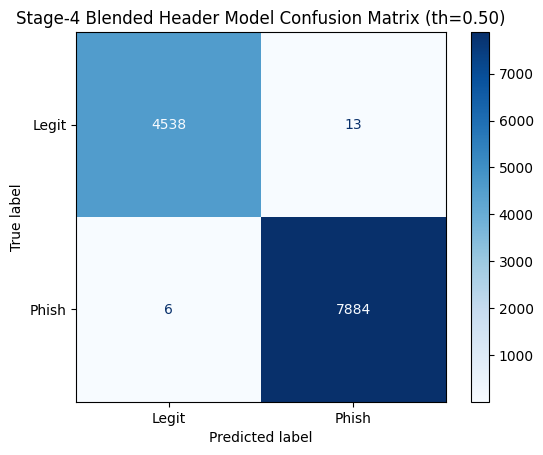


Classification report:
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00      4551
    Phishing       1.00      1.00      1.00      7890

    accuracy                           1.00     12441
   macro avg       1.00      1.00      1.00     12441
weighted avg       1.00      1.00      1.00     12441



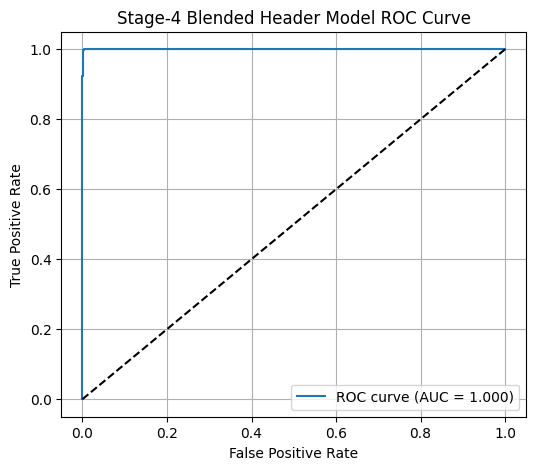

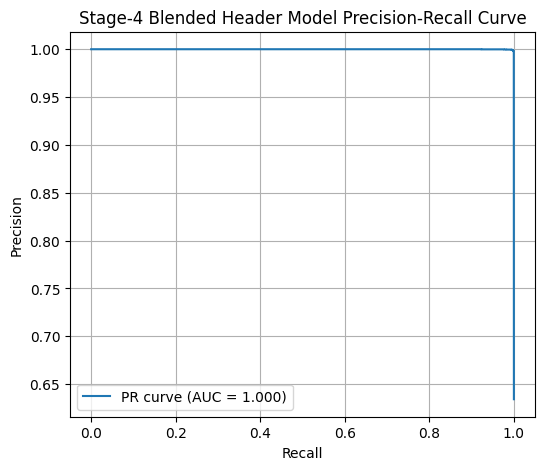


[INFO] Test metrics (threshold=0.5):
{'accuracy': 0.9984727915762398, 'precision': 0.9983538052424972, 'recall': 0.9992395437262357, 'f1': 0.9987964781149047, 'roc_auc': 0.9999662743518815, 'pr_auc': 0.9999801008076232}


In [116]:
print("\n[INFO] Evaluating blended model on TEST set...")
Z_test = get_blend_features(xgb_model, lgbm_model, X_test)

# Meta probabilities
test_probs = meta_clf.predict_proba(Z_test)[:, 1]

metrics_default = evaluate_probs(
    y_true=y_test,
    y_probs=test_probs,
    threshold=0.5,
    title_prefix="Stage-4 Blended Header Model",
)

print("\n[INFO] Test metrics (threshold=0.5):")
print(metrics_default)

# Threshold tuning (optional)


[INFO] Tuning threshold on validation set for best F1...
[INFO] Best threshold found: 0.175 (F1=0.9987)

[Stage-4 Blended Header Model (Tuned Threshold)] threshold=0.175
Accuracy : 0.9986
Precision: 0.9981
Recall   : 0.9996
F1       : 0.9989
Confusion Matrix:
 [[4536   15]
 [   3 7887]]


/home/defalt/.pyenv/versions/venv-3.10.12/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


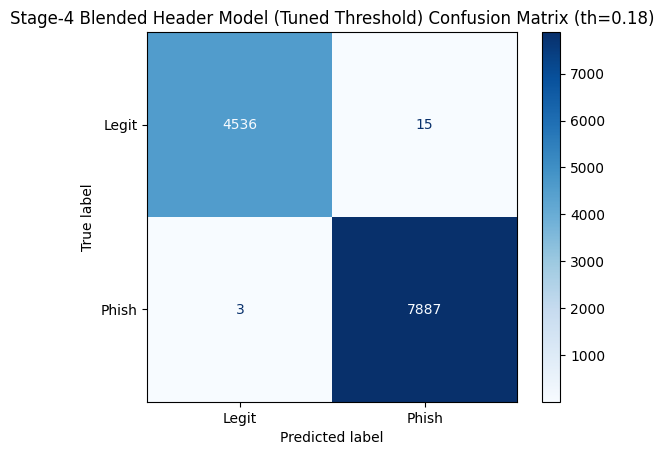


Classification report:
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00      4551
    Phishing       1.00      1.00      1.00      7890

    accuracy                           1.00     12441
   macro avg       1.00      1.00      1.00     12441
weighted avg       1.00      1.00      1.00     12441



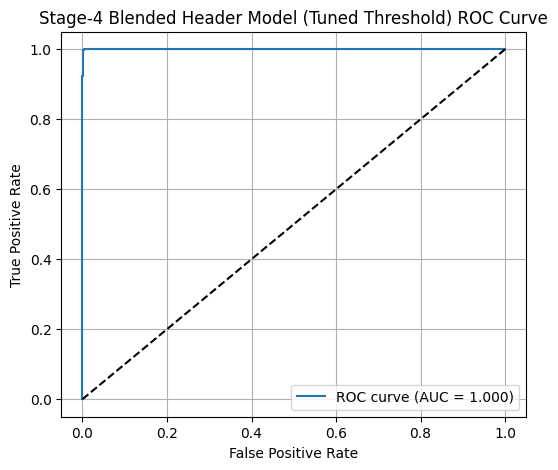

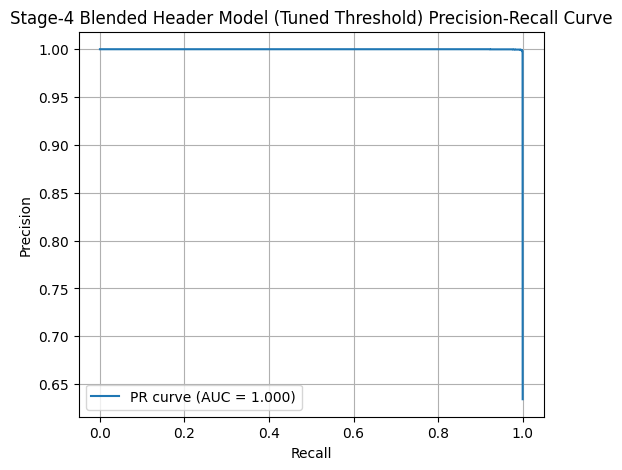


[INFO] Test metrics (tuned threshold):
{'accuracy': 0.998553170966964, 'precision': 0.9981017463933182, 'recall': 0.9996197718631179, 'f1': 0.9988601823708206, 'roc_auc': 0.9999662743518815, 'pr_auc': 0.9999801008076232}


In [117]:
print("\n[INFO] Tuning threshold on validation set for best F1...")
Z_val_full = get_blend_features(xgb_model, lgbm_model, X_val)
val_probs_full = meta_clf.predict_proba(Z_val_full)[:, 1]

best_th = 0.5
best_f1 = 0.0

for th in np.linspace(0.1, 0.9, 33):  # 0.1 to 0.9 step ~0.025
    preds = (val_probs_full >= th).astype(int)
    _, _, f1, _ = precision_recall_fscore_support(
        y_val, preds, average="binary", zero_division=0
    )
    if f1 > best_f1:
        best_f1 = f1
        best_th = th

print(f"[INFO] Best threshold found: {best_th:.3f} (F1={best_f1:.4f})")

# Evaluate again on test set using tuned threshold
metrics_tuned = evaluate_probs(
    y_true=y_test,
    y_probs=test_probs,
    threshold=best_th,
    title_prefix="Stage-4 Blended Header Model (Tuned Threshold)",
)
print("\n[INFO] Test metrics (tuned threshold):")
print(metrics_tuned)

# Save models + metadata

In [118]:
import joblib

print("\n[INFO] Saving models and metadata...")
joblib.dump(xgb_model, os.path.join(OUT_DIR, "header_xgb_model.pkl"))
joblib.dump(lgbm_model, os.path.join(OUT_DIR, "header_lgbm_model.pkl"))
joblib.dump(meta_clf, os.path.join(OUT_DIR, "header_meta_blender.pkl"))

with open(os.path.join(OUT_DIR, "header_feature_columns.json"), "w", encoding="utf-8") as f:
    json.dump(FEATURE_COLUMNS, f, ensure_ascii=False, indent=2)

with open(os.path.join(OUT_DIR, "header_threshold.json"), "w", encoding="utf-8") as f:
    json.dump({"best_threshold": float(best_th)}, f, indent=2)

print(f"[OK] Models & feature metadata saved to: {OUT_DIR}")


[INFO] Saving models and metadata...
[OK] Models & feature metadata saved to: header_stage4_models


# Feature importance

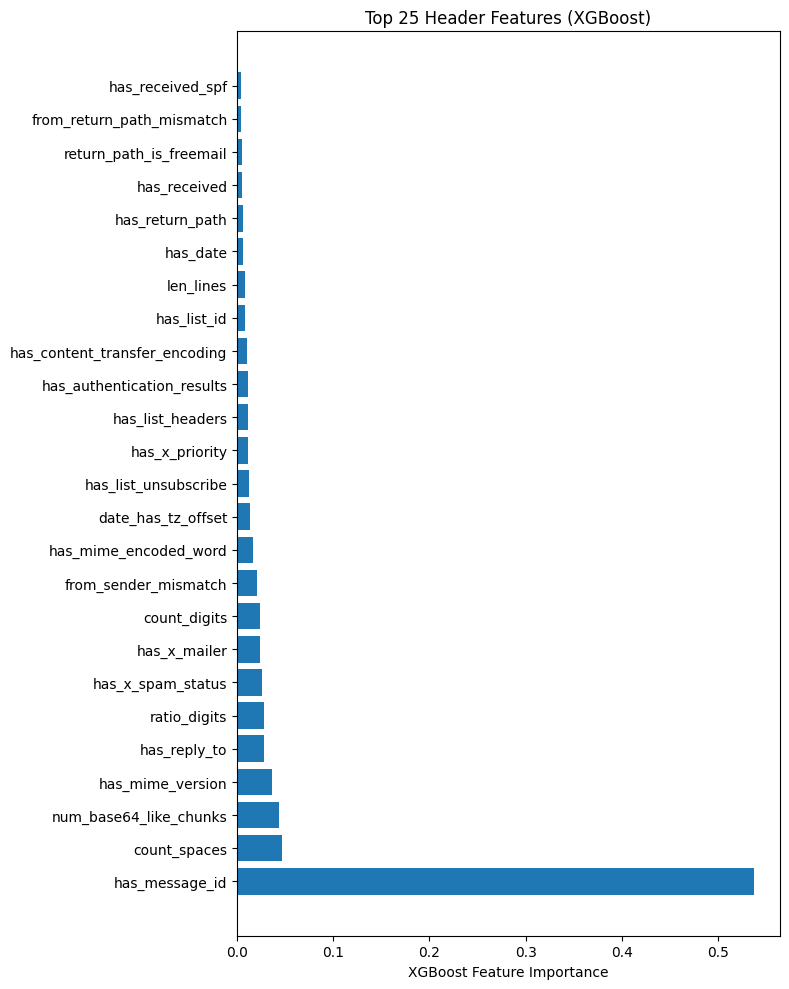

[INFO] SHAP not available, skipping SHAP plots.


In [119]:
# XGBoost feature importance
xgb_importances = xgb_model.feature_importances_
idx_sorted = np.argsort(xgb_importances)[::-1]

top_k = 25
top_idx = idx_sorted[:top_k]
top_feats = [FEATURE_COLUMNS[i] for i in top_idx]
top_vals  = xgb_importances[top_idx]

plt.figure(figsize=(8, 10))
plt.barh(range(len(top_feats))[::-1], top_vals[::-1])
plt.yticks(range(len(top_feats))[::-1], top_feats[::-1])
plt.xlabel("XGBoost Feature Importance")
plt.title("Top 25 Header Features (XGBoost)")
plt.tight_layout()
plt.show()

# Optional SHAP summary for a sample
if HAS_SHAP:
    print("\n[INFO] Computing SHAP values for a sample of test headers (this may take a while)...")
    
    # Get the booster object
    booster = xgb_model.get_booster()

    # Now create SHAP explainer
    explainer = shap.TreeExplainer(booster)
    
    # sample at most 1000 rows for SHAP to keep it fast
    sample_size = min(1000, X_test.shape[0])
    X_sample = X_test[:sample_size]

    shap_values = explainer.shap_values(X_sample)
    shap.summary_plot(shap_values, X_sample, feature_names=FEATURE_COLUMNS, show=True)
else:
    print("[INFO] SHAP not available, skipping SHAP plots.")

# Inference from .eml file

In [120]:
def extract_raw_headers_from_eml(path: str) -> str:
    """
    Minimal, robust header extraction from .eml without trusting Python's email parser.
    """
    try:
        with open(path, "rb") as f:
            lines = f.readlines()
    except Exception as e:
        print(f"[ERROR] Cannot read EML {path}: {e}")
        return ""

    header_bytes = b""
    for line in lines:
        header_bytes += line
        if line.strip() == b"":
            break

    try:
        headers_raw = header_bytes.decode("utf-8", errors="ignore")
    except Exception:
        headers_raw = ""

    return headers_raw


def predict_header_from_eml(
    eml_path: str,
    xgb_model=xgb_model,
    lgbm_model=lgbm_model,
    meta_clf=meta_clf,
    feature_columns=FEATURE_COLUMNS,
    threshold=best_th,
):
    """
    High-level helper: user passes .eml path → we extract headers,
    build features, run blended model, and return prediction dict.
    """
    headers_raw = extract_raw_headers_from_eml(eml_path)
    if not headers_raw.strip():
        return {
            "file": eml_path,
            "error": "No headers extracted",
        }

    feats_dict = extract_header_features(headers_raw)
    # Ensure all expected feature columns exist (fill missing with 0)
    x_vec = np.array([[feats_dict.get(col, 0.0) for col in feature_columns]], dtype=float)

    # base model probs
    p_xgb  = xgb_model.predict_proba(x_vec)[:, 1]
    p_lgbm = lgbm_model.predict_proba(x_vec)[:, 1]
    Z      = np.vstack([p_xgb, p_lgbm]).T

    p_phish = meta_clf.predict_proba(Z)[:, 1][0]
    pred    = int(p_phish >= threshold)

    return {
        "file": eml_path,
        "prediction": "PHISHING" if pred == 1 else "LEGIT",
        "prob_phishing": float(p_phish),
        "prob_legit": float(1.0 - p_phish),
        "threshold_used": float(threshold),
    }

print("\n[INFO] Stage-4 header model ready for inference.")

# Quick manual test (change path to one of your .eml samples)
example_path = "3s."
print(predict_header_from_eml(example_path))


[INFO] Stage-4 header model ready for inference.
{'file': '3s.', 'prediction': 'PHISHING', 'prob_phishing': 0.9985051700457123, 'prob_legit': 0.0014948299542877352, 'threshold_used': 0.17500000000000002}


/home/defalt/.pyenv/versions/venv-3.10.12/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
